# Speed Comparisions (VIP vs GRaTeR-JAX)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from vip_hci.fm.scattered_light_disk import ScatteredLightDisk as VIP_ScatteredLightDisk
from vip_hci.var.filters import frame_filter_lowpass

from grater_jax.optimization.optimize_framework import Optimizer
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk as JAX_ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import (
    DustEllipticalDistribution2PowerLaws,
    HenyeyGreenstein_SPF,
)
from grater_jax.disk_model.objective_functions import Parameter_Index
import jax
import os

os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.50'
jax.config.update("jax_enable_x64", True)


/home/mihirkondapalli/anaconda3/envs/package-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-29 00:55:29.356320: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Model Generation Benchmarks

In [2]:
density = {
    "name": "2PowerLaws",
    "a": 60.0,
    "ksi0": 1.0,
    "gamma": 2.0,
    "beta": 1.0,
    "ain": 5.0,
    "aout": -5.0,
    "e": 0.0,
    "dens_at_r0": 1.0,
}
phase = {"name": "HG", "g": 0.3, "polar": False}

vip_disk = VIP_ScatteredLightDisk(
    nx=200,
    ny=200,
    distance=50.0,
    itilt=60.0,
    omega=0.0,
    pxInArcsec=0.01225,
    pa=0.0,
    density_dico=density,
    spf_dico=phase,
    xdo=0.0,
    ydo=0.0,
)
vip_img = vip_disk.compute_scattered_light(halfNbSlices=25)

In [3]:
# Define Optimizer inputs
spf_params = HenyeyGreenstein_SPF.params.copy()
spf_params["g"] = 0.3

disk_params = Parameter_Index.disk_params.copy()
misc_params = Parameter_Index.misc_params.copy()

disk_params.update(
    {
        "sma": 60.0,
        "alpha_in": 5.0,
        "alpha_out": -5.0,
        "ksi0": 1.0,
        "gamma": 2.0,
        "beta": 1.0,
        "e": 0.0,
        "dens_at_r0": 1.0,
        "inclination": 60.0,
        "position_angle": 0.0,
        "omega": 0.0,
        "x_center": 100.0,
        "y_center": 100.0,
        "halfNbSlices": 25,
    }
)

misc_params.update(
    {
        "distance": 50.0,
        "pxInArcsec": 0.01225,
        "nx": 200,
        "ny": 200,
        "halfNbSlices": 25,
        "flux_scaling": 1,
    }
)

optimizer = Optimizer(
    DiskModel=JAX_ScatteredLightDisk,
    DistrModel=DustEllipticalDistribution2PowerLaws,
    FuncModel=HenyeyGreenstein_SPF,
    PSFModel=None,
    disk_params=disk_params,
    spf_params=spf_params,
    psf_params=None,
    misc_params=misc_params,
)

In [4]:
# Generate JAX model
jax_img = optimizer.get_model()

# Compute likelihood
err_map = np.ones_like(vip_img) * np.nanstd(vip_img)
ll = optimizer.log_likelihood(vip_img, err_map)
print("Log-likelihood:", ll)

# Compare residuals
residual = vip_img - jax_img
mean_resid = np.mean(np.abs(residual))
max_resid = np.max(np.abs(residual))
print("Mean residual:", mean_resid)
print("Max residual:", max_resid)

Log-likelihood: 11.269991291554023
Mean residual: 4.1291199921774543e-13
Max residual: 3.401922725454736e-12


### GRaTeR-JAX vs VIP Models

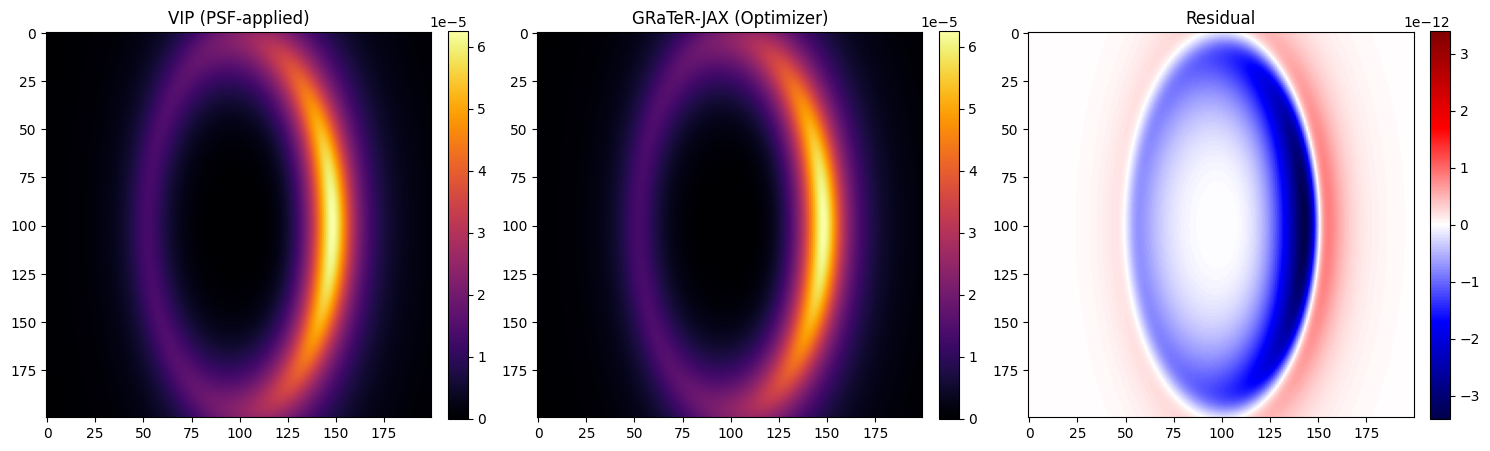

In [5]:
# Visualization
vmin = min(vip_img.min(), jax_img.min())
vmax = max(vip_img.max(), jax_img.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(vip_img, cmap="inferno", vmin=vmin, vmax=vmax)
axes[0].set_title("VIP (PSF-applied)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(jax_img, cmap="inferno", vmin=vmin, vmax=vmax)
axes[1].set_title("GRaTeR-JAX (Optimizer)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(residual, cmap="seismic", vmin=-max_resid, vmax=max_resid)
axes[2].set_title("Residual")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### GRaTeR-JAX vs VIP Runtimes

In [6]:
%timeit vip_disk.compute_scattered_light(halfNbSlices=25)
%timeit optimizer.get_model()

129 ms ± 118 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.66 ms ± 2.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## GRaTeR-JAX vs VIP Gradient Benchmarks

In [7]:
from vip_hci.fm.scattered_light_disk import ScatteredLightDisk as VIP_ScatteredLightDisk
from grater_jax.optimization.optimize_framework import Optimizer, OptimizeUtils
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
from grater_jax.disk_model.SLD_utils import (
    DustEllipticalDistribution2PowerLaws,
    InterpolatedUnivariateSpline_SPF,
    EMP_PSF,
)
from grater_jax.disk_model.objective_functions import Parameter_Index

# Synthetic target
def generate_vip_synthetic_target(nx=200, ny=200):
    density = {
        "name": "2PowerLaws",
        "a": 60.0,
        "ksi0": 1.0,
        "gamma": 2.0,
        "beta": 1.0,
        "ain": 5.0,
        "aout": -5.0,
        "e": 0.0,
        "dens_at_r0": 1.0,
    }
    phase = {"name": "HG", "g": 0.3, "polar": False}

    vip_disk = VIP_ScatteredLightDisk(
        nx=nx, ny=ny,
        distance=50.0,
        itilt=60.0,
        omega=0.0,
        pxInArcsec=0.01225,
        pa=0.0,
        density_dico=density,
        spf_dico=phase,
        xdo=0.0, ydo=0.0
    )

    vip_img = vip_disk.compute_scattered_light(halfNbSlices=25)
    return vip_img


In [8]:
# Synthetic VIP target
target_image = generate_vip_synthetic_target(nx=200, ny=200)
err_map = np.ones_like(target_image, dtype=np.float32)

# GRaTeR-JAX parameter setup
start_disk_params = Parameter_Index.disk_params.copy()
start_spf_params  = InterpolatedUnivariateSpline_SPF.params.copy()

# No PSF → both the class and params are None
start_psf_params  = None

start_misc_params = Parameter_Index.misc_params.copy()

start_disk_params.update({
    "sma": 46.0,
    "inclination": 80.0,
    "position_angle": 27.5,
    "x_center": 100.0,
    "y_center": 100.0,
    "flux_scaling": 1.0,
})

start_spf_params["num_knots"] = 5
start_spf_params["knot_values"] = np.ones(5) * 0.5

start_misc_params.update({
    "distance": 50.0,
    "nx": 200,
    "ny": 200,
    "pxInArcsec": 0.01225,
})

# Initialize optimizer with NO PSF model
opt = Optimizer(
    ScatteredLightDisk,
    DustEllipticalDistribution2PowerLaws,
    InterpolatedUnivariateSpline_SPF,
    PSFModel=None,
    disk_params=start_disk_params,
    spf_params=start_spf_params,
    psf_params=start_psf_params,
    misc_params=start_misc_params,
)

# SPF knots
opt.inc_bound_knots()
opt.initialize_knots(target_image)

# Compile model + gradient (no PSF path)
opt.jit_compile_model()
opt.jit_compile_gradient(target_image, err_map)

In [9]:
from grater_jax.disk_model.objective_functions import log_likelihood

In [10]:
fit_keys = ["sma", "alpha_in", "inclination", "position_angle", "x_center", "y_center", "alpha_out", "knot_values"]

def analytic_grad():
    return opt.get_gradient(fit_keys, target_image, err_map)

def numeric_grad(eps=1e-6):
    """
    Finite-difference numerical gradient for the current optimizer state.
    Supports both scalar parameters and vector-valued knot_values.
    """

    base_params = opt.get_values(keys=fit_keys)
    grad = []

    for k in range(len(fit_keys)):
        val = base_params[k]

        if np.isscalar(val):
            params_plus = base_params.copy()
            params_minus = base_params.copy()

            params_plus[k] = val + eps
            params_minus[k] = val - eps

            ll_plus = opt.get_objective_likelihood(
                params_plus, fit_keys, target_image, err_map
            )
            ll_minus = opt.get_objective_likelihood(
                params_minus, fit_keys, target_image, err_map
            )

            grad.append((ll_plus - ll_minus) / (2 * eps))
        else:
            g = np.zeros_like(val)
            for i in range(len(val)):
                params_plus = base_params.copy()
                params_minus = base_params.copy()
                v_plus = val.at[i].set(val[i] + eps)
                v_minus = val.at[i].set(val[i] - eps)
                params_plus[k] = v_plus
                params_minus[k] = v_minus
                ll_plus = opt.get_objective_likelihood(
                    params_plus, fit_keys, target_image, err_map
                )
                ll_minus = opt.get_objective_likelihood(
                    params_minus, fit_keys, target_image, err_map
                )
                g[i] = (ll_plus - ll_minus) / (2 * eps)
            grad.append(g)

    return grad


In [11]:
def make_vip_disk(params_dict):
    density = {
        "name": "2PowerLaws",
        "a": params_dict["sma"],
        "ksi0": 1.0,
        "gamma": 2.0,
        "beta": 1.0,
        "ain": params_dict["alpha_in"],
        "aout": params_dict["alpha_out"],
        "e": 0.0,
        "dens_at_r0": 1.0,
    }

    phase = {
        "name": "HG",
        "g": params_dict["g"],
        "polar": False,    }

    return VIP_ScatteredLightDisk(
        nx=200,
        ny=200,
        distance=50.0,
        itilt=params_dict["inclination"],
        omega=0.0,
        pxInArcsec=0.01225,
        pa=params_dict["position_angle"],
        density_dico=density,
        spf_dico=phase,
        xdo=100-params_dict["x_center"],
        ydo=100-params_dict["y_center"]
    )

vip_fit_keys = ["sma", "alpha_in", "inclination", "position_angle", "x_center", "y_center", "alpha_out", "g"]
vip_fit_values = [46.0, 5.0, 80.0, 27.5, 100.0, 100.0, -5.0, 0.3]
base_dict = dict(zip(vip_fit_keys, vip_fit_values))

def numeric_grad_vip(eps=1e-6):
    """
    Finite-difference numerical gradient using VIP scattered-light images.
    """
    grad = []

    for k, key in enumerate(vip_fit_keys):
        val = vip_fit_values[k]

        if np.isscalar(val):
            dict_plus = dict(base_dict)
            dict_minus = dict(base_dict)
            dict_plus[key] = val + eps
            dict_minus[key] = val - eps

            img_plus = make_vip_disk(dict_plus).compute_scattered_light(halfNbSlices=25)
            img_minus = make_vip_disk(dict_minus).compute_scattered_light(halfNbSlices=25)

            ll_plus = log_likelihood(img_plus, target_image, err_map)
            ll_minus = log_likelihood(img_minus, target_image, err_map)

            grad.append((ll_plus - ll_minus) / (2 * eps))

    return grad


### Numeric vs Analytic Gradients

VIP does not have the capability to generate numeric gradients, so I will isolate the performance improvement of GRaTeR-JAX's analyitic gradient function by comparing the analyitic gradient with a numeric function for a GRaTeR-JAX objective function.

In [12]:
def compress_grad(grad_list):
    out = []
    for g in grad_list:
        if np.isscalar(g):
            out.append(float(g))
        else:
            out.extend(np.asarray(g).ravel().astype(float).tolist())
    return out

def format_list(vals, ndigits=2):
    return "[" + ", ".join(f"{v:.{ndigits}e}" for v in vals) + "]"

print("Analytic Gradient:", format_list(compress_grad(analytic_grad()), 2))
print("Numeric Gradient:",  format_list(compress_grad(numeric_grad()), 2))


Analytic Gradient: [1.41e-12, 3.40e-12, -2.45e-12, 3.56e-13, 3.42e-13, -1.06e-13, 1.01e-14, -3.40e-12, -2.38e-13, 2.01e-12, 1.56e-12, 1.38e-13]
Numeric Gradient: [1.41e-12, 3.40e-12, -2.45e-12, 3.56e-13, 8.22e-13, 2.30e-14, 1.01e-14, -3.40e-12, -2.38e-13, 2.01e-12, 1.56e-12, 1.38e-13]


### VIP (numeric) vs GRaTeR-JAX Gradient Runtimes

In [14]:
%timeit numeric_grad()
%timeit analytic_grad()
%timeit numeric_grad_vip()

159 ms ± 614 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
29 ms ± 28.9 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.08 s ± 9.76 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


# Performance Takeaways

GRaTeR-JAX delivers substantial performance improvements over the legacy VIP GRaTeR disk framework in both **model generation** and **gradient evaluation**. These gains are enabled by JAX-based vectorization, XLA compilation, and analytic differentiation, making GRaTeR-JAX significantly more scalable for optimization and inference workflows.

---

## Benchmark Summary

| Task | Framework | Method | Runtime per Loop | Speedup |
|-----:|-----------|--------|------------------|---------|
| Model generation | VIP GRaTeR | Native | 104 ms ± 99.9 μs | 1× |
| Model generation | GRaTeR-JAX | JAX model | 2.67 ms ± 1.97 μs | **~39×** |
| Gradient | VIP GRaTeR | Numeric (FD) | 1.71 s ± 4.06 ms | 1× |
| Gradient | GRaTeR-JAX | Numeric (FD) | 159 ms ± 777 μs | ~11× |
| Gradient | GRaTeR-JAX | Analytic (AD) | 29.1 ms ± 17.6 μs | **~59×** |

---

## Model Generation Performance

We compare scattered-light model generation between:

- **VIP GRaTeR**: `vip_disk.compute_scattered_light`
- **GRaTeR-JAX**: `optimizer.get_model`

```python
%timeit vip_disk.compute_scattered_light(halfNbSlices=25)
%timeit optimizer.get_model()
```

**Results**

- VIP GRaTeR  
  104 ms ± 99.9 μs per loop  
  (mean ± std. dev. of 7 runs, 10 loops each)

- GRaTeR-JAX  
  2.67 ms ± 1.97 μs per loop  
  (mean ± std. dev. of 7 runs, 100 loops each)

**Speedup**

GRaTeR-JAX achieves a **~39× reduction** in model generation runtime.

This improvement dramatically reduces the cost of iterative workflows such as gradient-based fitting, MCMC sampling, and large-scale parameter sweeps.

---

## Gradient Computation Performance

Three gradient computation scenarios are evaluated:

```python
%timeit numeric_grad()
%timeit analytic_grad()
%timeit numeric_grad_vip()
```

**Results**

- GRaTeR-JAX numeric gradient  
  159 ms ± 777 μs per loop  
  (7 runs, 10 loops each)

- GRaTeR-JAX analytic gradient  
  29.1 ms ± 17.6 μs per loop  
  (7 runs, 10 loops each)

- VIP numeric gradient  
  1.71 s ± 4.06 ms per loop  
  (7 runs, 1 loop each)

### Notes on Comparability

- The **numeric and analytic gradients** are computed on the **same GRaTeR-JAX model**, allowing for a direct comparison (12 parameters).
- The **VIP numeric gradient** corresponds to a different model configuration (8 parameters), as VIP does **not support spline-based SPF functions**. It is included as a realistic reference for legacy workflows rather than a strict apples-to-apples comparison.

---

## Gradient Speedups

- **Analytic vs numeric (GRaTeR-JAX)**  
  → **~5.6× speedup** for a 12-parameter fit

- **Analytic GRaTeR-JAX vs numeric VIP**  
  → **~59× speedup** in gradient evaluation

In addition to performance gains, analytic gradients eliminate numerical instability and poor scaling behavior inherent to finite-difference methods.

---

## Summary

- Model generation is nearly **40× faster** with GRaTeR-JAX.
- Analytic gradients provide:
  - Significant runtime reductions
  - Improved numerical stability
  - Better scaling with parameter dimensionality
- GRaTeR-JAX enables workflows that are impractical with VIP, including high-dimensional optimization, HMC/NUTS sampling, and interactive modeling.

Overall, GRaTeR-JAX represents a substantial advance in both **performance** and **scalability** for scattered-light disk modeling.
